# Exploratory Data Analysis (EDA)

## Objective
After extractng `les-arbres` data from Paris Open Data API, let's analyze it. Our goal is to understand the data and identify possible errors/outliers, and even ideas worth exploring later on our visualization.

## Import Libraries, Set Up DuckDB Connection

In [70]:
import duckdb
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns

# Connect to duckdb instance
con = duckdb.connect()

parquet_path = Path.cwd() / "data/raw/trees_raw.parquet"


In [8]:
# Query the parquet file and output to Pandas DataFrame to render in notebook
query = f"""
    SELECT * FROM  '{parquet_path}'
"""

df = con.query(query).df()

In [9]:
df.head()

,IDBASE,TYPE EMPLACEMENT,DOMANIALITE,ARRONDISSEMENT,COMPLEMENT ADRESSE,LIEU / ADRESSE,IDEMPLACEMENT,LIBELLE FRANCAIS,GENRE,ESPECE,VARIETE OUCULTIVAR,CIRCONFERENCE (cm),HAUTEUR (m),STADE DE DEVELOPPEMENT,REMARQUABLE,geo_point_2d
0,2033164,Arbre,Jardin,PARIS 7E ARRDT,NaN,JARDIN DU POTAGER / 29 RUE DE BABYLONE,000208002,NaN,Malus,NaN,''Red Sentinel'',70,4,Jeune (arbre),NON,"48.85052442180247, 2.3211374979168564"
1,231753,Arbre,Alignement,PARIS 15E ARRDT,N°74,AVENUE ALBERT BARTHOLOME,000402045,Micocoulier,Celtis,australis,NaN,110,12,Adulte,NON,"48.82791216031944, 2.2984486155997472"
2,244574,Arbre,Alignement,PARIS 19E ARRDT,NaN,PLACE RHIN ET DANUBE,000602001,Platane,Platanus,x hispanica,NaN,130,18,Adulte,NON,"48.881840414361555, 2.3929673330988863"
3,106369,Arbre,Jardin,PARIS 7E ARRDT,Canton 10,JARDIN DU CHAMP DE MARS ET PELOUSES DE L ECOLE...,A01005025,Sophora,Styphnolobium,japonicum,NaN,150,12,Adulte,NON,"48.852562156573256, 2.3014345987170173"
4,120264,Arbre,Jardin,PARIS 18E ARRDT,NaN,SQUARE DE LA RUE HENRI HUCHARD / 25 RUE LOUIS ...,000107002,Cerisier à fleurs,Prunus,NaN,''Kanzan'',171,8,Adulte,NON,"48.89970138812048, 2.3306664255488423"


## Structure Investigation

In [14]:
# Show size of dataset
print(f"There are {df.shape[0]} rows and {df.shape[1]} features.")

There are 217852 rows and 16 features.


For each of these features, how many different data types are there?

In [16]:
df.dtypes.value_counts()

str      13
Int64     2
int64     1
Name: count, dtype: int64

### Non-numerical features

In [17]:
df.select_dtypes(exclude="number").head()

,TYPE EMPLACEMENT,DOMANIALITE,ARRONDISSEMENT,COMPLEMENT ADRESSE,LIEU / ADRESSE,IDEMPLACEMENT,LIBELLE FRANCAIS,GENRE,ESPECE,VARIETE OUCULTIVAR,STADE DE DEVELOPPEMENT,REMARQUABLE,geo_point_2d
0,Arbre,Jardin,PARIS 7E ARRDT,NaN,JARDIN DU POTAGER / 29 RUE DE BABYLONE,000208002,NaN,Malus,NaN,''Red Sentinel'',Jeune (arbre),NON,"48.85052442180247, 2.3211374979168564"
1,Arbre,Alignement,PARIS 15E ARRDT,N°74,AVENUE ALBERT BARTHOLOME,000402045,Micocoulier,Celtis,australis,NaN,Adulte,NON,"48.82791216031944, 2.2984486155997472"
2,Arbre,Alignement,PARIS 19E ARRDT,NaN,PLACE RHIN ET DANUBE,000602001,Platane,Platanus,x hispanica,NaN,Adulte,NON,"48.881840414361555, 2.3929673330988863"
3,Arbre,Jardin,PARIS 7E ARRDT,Canton 10,JARDIN DU CHAMP DE MARS ET PELOUSES DE L ECOLE...,A01005025,Sophora,Styphnolobium,japonicum,NaN,Adulte,NON,"48.852562156573256, 2.3014345987170173"
4,Arbre,Jardin,PARIS 18E ARRDT,NaN,SQUARE DE LA RUE HENRI HUCHARD / 25 RUE LOUIS ...,000107002,Cerisier à fleurs,Prunus,NaN,''Kanzan'',Adulte,NON,"48.89970138812048, 2.3306664255488423"


We should divide coordinates into two specific columns.

In [19]:
coords = df["geo_point_2d"].str.split(",", expand=True)
df["latitude"] = pd.to_numeric(coords[0])
df["longitude"] = pd.to_numeric(coords[1])

df.drop("geo_point_2d", axis=1, inplace=True)

In [21]:
df.describe(exclude='number')

,TYPE EMPLACEMENT,DOMANIALITE,ARRONDISSEMENT,COMPLEMENT ADRESSE,LIEU / ADRESSE,IDEMPLACEMENT,LIBELLE FRANCAIS,GENRE,ESPECE,VARIETE OUCULTIVAR,STADE DE DEVELOPPEMENT,REMARQUABLE
count,217852,217851,217852,74980,217852,217851,214266,217849,213030,39144,174999,203173
unique,1,9,25,6100,7678,62763,234,203,634,607,4,2
top,Arbre,Alignement,PARIS 13E ARRDT,Nouveau,PARC FLORAL DE PARIS / ROUTE DE LA PYRAMIDE,000101001,Platane,Platanus,x hispanica,''Baumannii'',Adulte,NON
freq,217852,110072,18132,1450,2932,2749,42741,42757,38170,4884,84693,202990


### Numerical features

<Axes: >

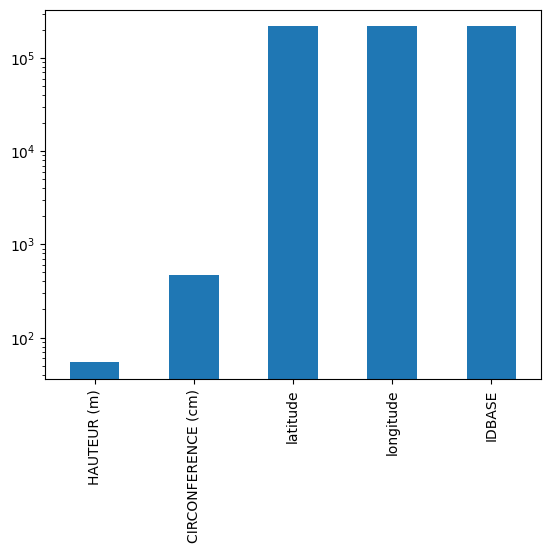

In [26]:
unique_values = df.select_dtypes(include="number").nunique().sort_values()

unique_values.plot.bar(logy=True)

In [34]:
df.describe(include='number')

,IDBASE,CIRCONFERENCE (cm),HAUTEUR (m),latitude,longitude
count,2.178520e+05,217851.0,217851.0,217851.000000,217851.000000
mean,5.762748e+05,82.362408,9.061244,48.855299,2.347302
std,7.332743e+05,63.275888,23.972344,0.029953,0.051254
min,9.987400e+04,0.0,0.0,48.742290,2.210241
25%,1.641798e+05,31.0,5.0,48.835677,2.307234
50%,2.366835e+05,73.0,8.0,48.855218,2.350696
75%,2.941802e+05,117.0,12.0,48.877090,2.385823
max,2.055199e+06,2066.0,10778.0,48.912160,2.469752


We'll probably work with `hauteur` and `circonference`. `IDBASE` can be used for unique count of trees. The others are just coordinates.

## Quality Investigation

### Duplicates

In [27]:
# Check number of duplicates while ignoring index feature
n_duplicates = df.drop(labels=["IDBASE"], axis=1).duplicated().sum()

print(f"There seem to have {n_duplicates} in the database.")


There seem to have 0 in the database.


### Missing values

#### Per Sample

Text(0, 0.5, 'Sample Number')

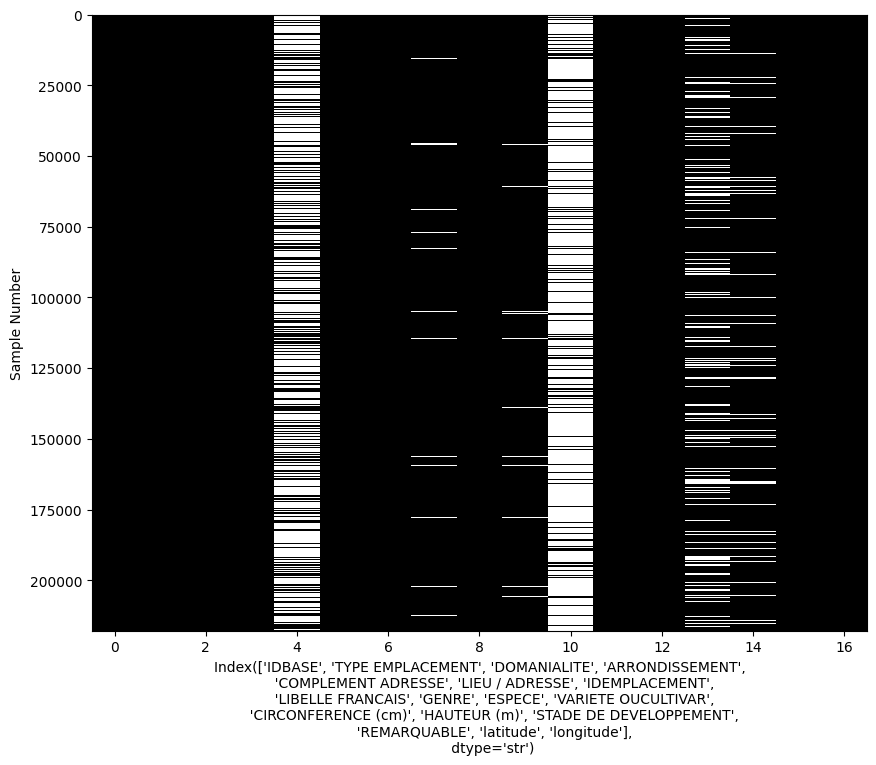

In [37]:
plt.figure(figsize=(10, 8))
plt.imshow(df.isna(), aspect="auto", interpolation="nearest", cmap="gray")
plt.xlabel(df.columns)
plt.ylabel("Sample Number")

<Axes: >

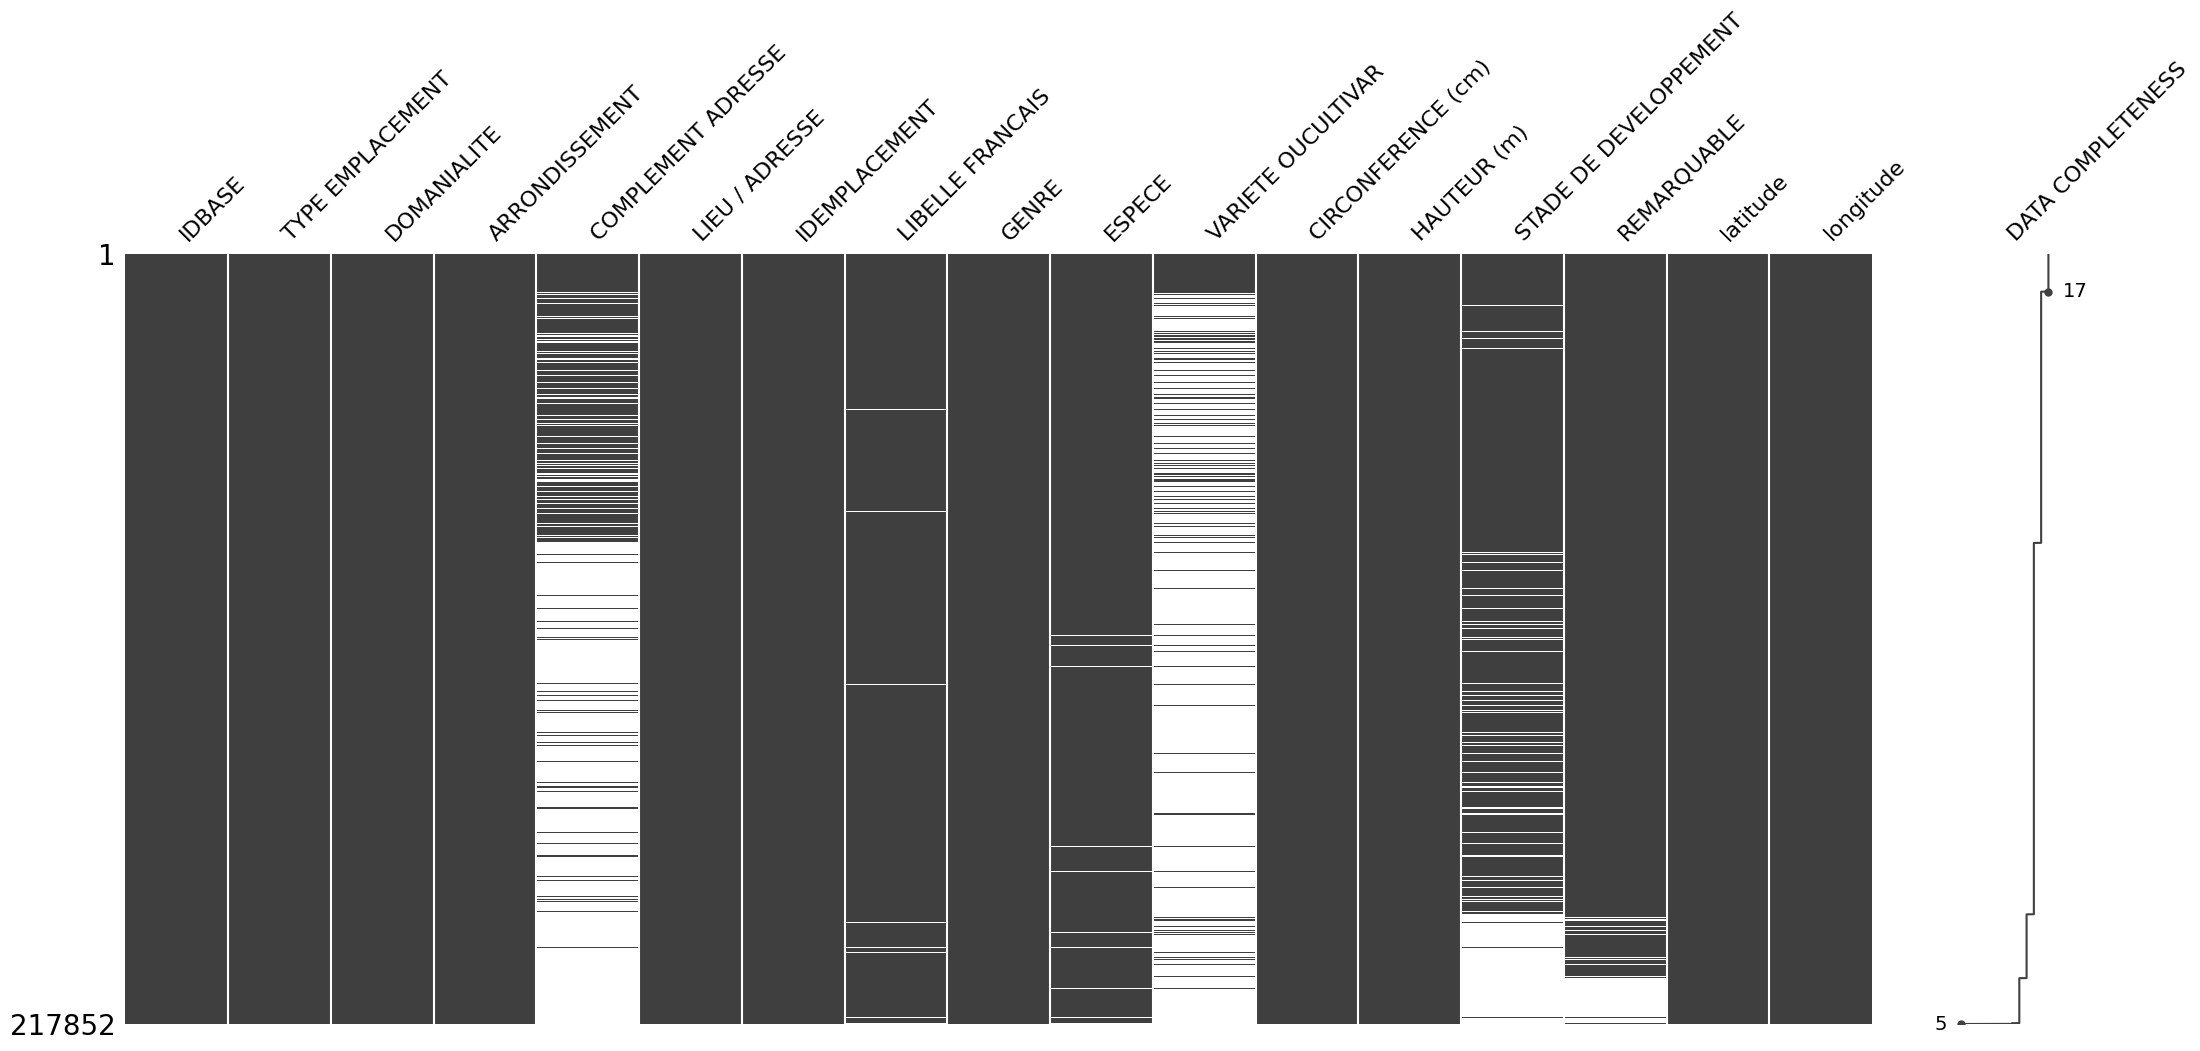

In [40]:
msno.matrix(df, labels=True, sort="descending")

#### Per Feature

<Axes: title={'center': 'Percentage of missing values per feature'}, ylabel='Ratio of missing values per feature'>

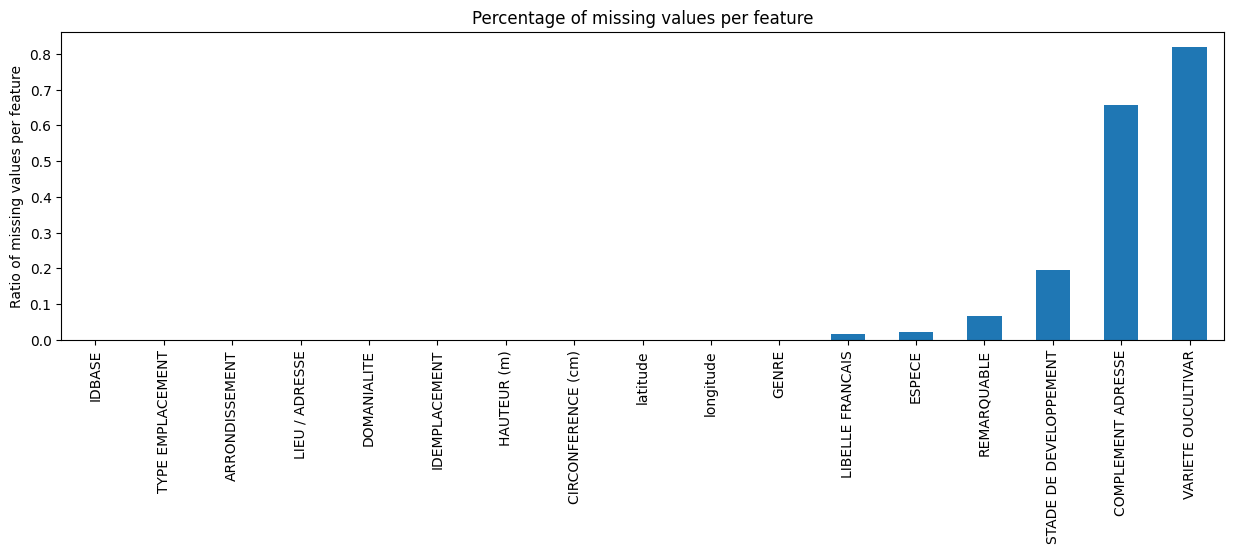

In [41]:
df.isna().mean().sort_values().plot(
    kind="bar", figsize=(15, 4),
    title="Percentage of missing values per feature",
    ylabel="Ratio of missing values per feature"
)

Note: by this point, we are pretty sure we won't work with `COMPLEMENT_ADRESSE`, `VARIETE_OUCULTIVAR`. We can discard all fields that are related to address, type of type emplacement, complement adresse, lieu  / adresse, idemplacement, variete oucultivar, remarquable. We can drop this columns.

In [43]:
df.head(2)

,IDBASE,TYPE EMPLACEMENT,DOMANIALITE,ARRONDISSEMENT,COMPLEMENT ADRESSE,LIEU / ADRESSE,IDEMPLACEMENT,LIBELLE FRANCAIS,GENRE,ESPECE,VARIETE OUCULTIVAR,CIRCONFERENCE (cm),HAUTEUR (m),STADE DE DEVELOPPEMENT,REMARQUABLE,latitude,longitude
0,2033164,Arbre,Jardin,PARIS 7E ARRDT,NaN,JARDIN DU POTAGER / 29 RUE DE BABYLONE,000208002,NaN,Malus,NaN,''Red Sentinel'',70,4,Jeune (arbre),NON,48.850524,2.321137
1,231753,Arbre,Alignement,PARIS 15E ARRDT,N°74,AVENUE ALBERT BARTHOLOME,000402045,Micocoulier,Celtis,australis,NaN,110,12,Adulte,NON,48.827912,2.298449


In [45]:
drop_features = ["TYPE_EMPLACEMENT", "COMPLEMENT ADRESSE", "LIEU / ADRESSE", "IDEMPLACEMENT", "VARIETE OUCULTIVAR", "REMARQUABLE"]
cols_to_drop = [c for c in df.columns if any(p in c.upper() for p in drop_features)]
df.drop(columns=cols_to_drop, inplace=True)

In [46]:
df.head()

,IDBASE,TYPE EMPLACEMENT,DOMANIALITE,ARRONDISSEMENT,LIBELLE FRANCAIS,GENRE,ESPECE,CIRCONFERENCE (cm),HAUTEUR (m),STADE DE DEVELOPPEMENT,latitude,longitude
0,2033164,Arbre,Jardin,PARIS 7E ARRDT,NaN,Malus,NaN,70,4,Jeune (arbre),48.850524,2.321137
1,231753,Arbre,Alignement,PARIS 15E ARRDT,Micocoulier,Celtis,australis,110,12,Adulte,48.827912,2.298449
2,244574,Arbre,Alignement,PARIS 19E ARRDT,Platane,Platanus,x hispanica,130,18,Adulte,48.881840,2.392967
3,106369,Arbre,Jardin,PARIS 7E ARRDT,Sophora,Styphnolobium,japonicum,150,12,Adulte,48.852562,2.301435
4,120264,Arbre,Jardin,PARIS 18E ARRDT,Cerisier à fleurs,Prunus,NaN,171,8,Adulte,48.899701,2.330666


### Unwanted entries and recording errors
#### Numerical features

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

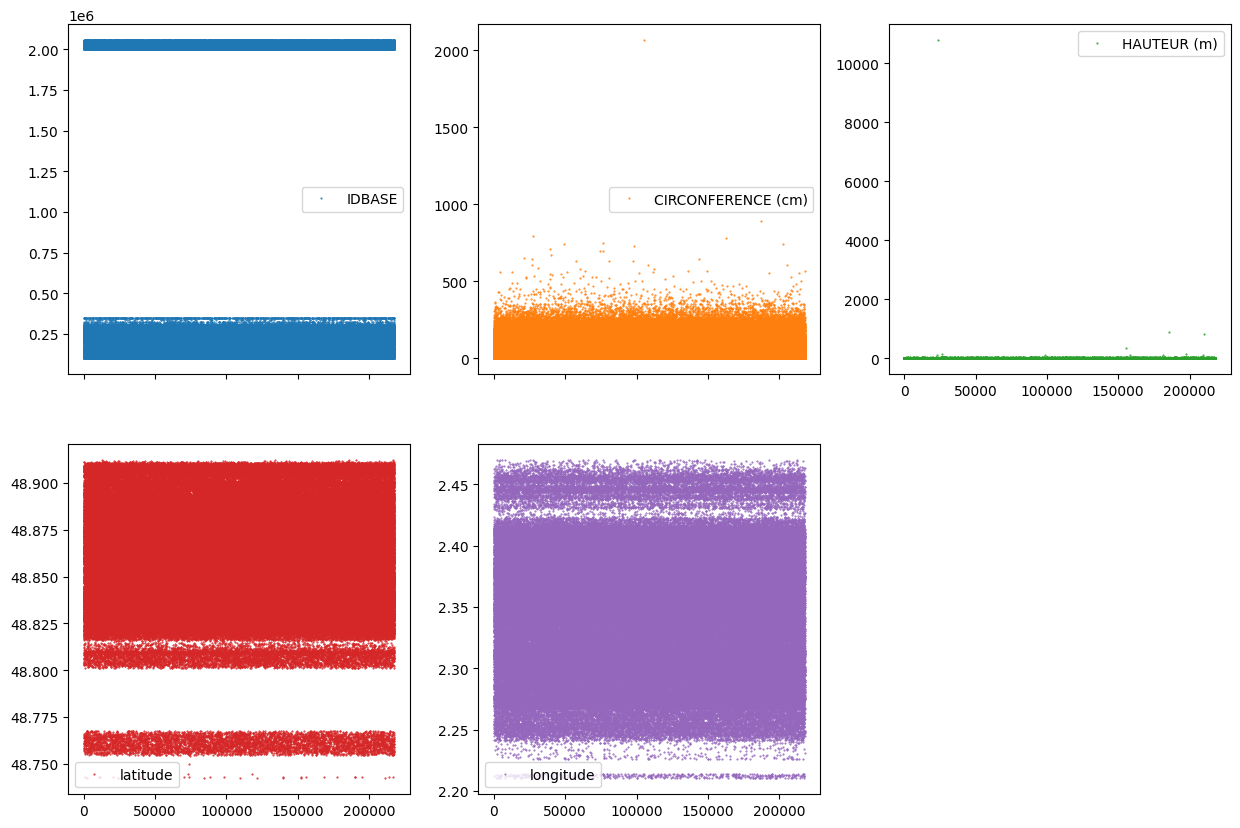

In [52]:
df.plot(lw=0, marker=".", subplots=True, layout=(-1, 3),
        figsize=(15, 10), markersize=1)

In [59]:
df.loc[df["HAUTEUR (m)"] > 40]

,IDBASE,TYPE EMPLACEMENT,DOMANIALITE,ARRONDISSEMENT,LIBELLE FRANCAIS,GENRE,ESPECE,CIRCONFERENCE (cm),HAUTEUR (m),STADE DE DEVELOPPEMENT,latitude,longitude
23238,293298,Arbre,Alignement,PARIS 18E ARRDT,Marronnier,Aesculus,hippocastanum,115,110,Mature,48.889698,2.343504
23802,273832,Arbre,Alignement,PARIS 12E ARRDT,Marronnier,Aesculus,hippocastanum,120,10778,Adulte,48.847338,2.404858
26170,2043155,Arbre,DASCO,PARIS 3E ARRDT,Poirier à fruits,Pyrus,communis,12,150,Jeune (arbre),48.859286,2.360957
28364,2002389,Arbre,Jardin,BOIS DE BOULOGNE,Platane,Platanus,x hispanica,535,45,Mature,48.867118,2.252942
88247,184174,Arbre,DASCO,PARIS 17E ARRDT,Arbre de Judée,Cercis,siliquastrum,61,61,Jeune (arbre),48.886995,2.311264
98947,285480,Arbre,Alignement,PARIS 18E ARRDT,Tilleul,Tilia,tomentosa,131,120,Mature,48.888006,2.348604
145306,269231,Arbre,Alignement,PARIS 11E ARRDT,Tilleul,Tilia,tomentosa,50,58,Jeune (arbre),48.863424,2.383821
155314,2053848,Arbre,Alignement,PARIS 13E ARRDT,Cerisier à grappes,Prunus,padus,10,350,Jeune (arbre),48.822365,2.346965
156394,194364,Arbre,PERIPHERIQUE,PARIS 20E ARRDT,Mûrier,Morus,sp.,180,57,Adulte,48.858322,2.413912
158207,245120,Arbre,Alignement,PARIS 16E ARRDT,Marronnier,Aesculus,hippocastanum,134,118,Adulte,48.857163,2.265974


In [56]:
df.loc[df["CIRCONFERENCE (cm)"] > 1000]

,IDBASE,TYPE EMPLACEMENT,DOMANIALITE,ARRONDISSEMENT,LIBELLE FRANCAIS,GENRE,ESPECE,CIRCONFERENCE (cm),HAUTEUR (m),STADE DE DEVELOPPEMENT,latitude,longitude
105261,274848,Arbre,Alignement,PARIS 2E ARRDT,Micocoulier,Celtis,australis,2066,16,Adulte,48.865535,2.344846


#### Non-numerical data

In [60]:
df.describe(exclude='number')

,TYPE EMPLACEMENT,DOMANIALITE,ARRONDISSEMENT,LIBELLE FRANCAIS,GENRE,ESPECE,STADE DE DEVELOPPEMENT
count,217852,217851,217852,214266,217849,213030,174999
unique,1,9,25,234,203,634,4
top,Arbre,Alignement,PARIS 13E ARRDT,Platane,Platanus,x hispanica,Adulte
freq,217852,110072,18132,42741,42757,38170,84693


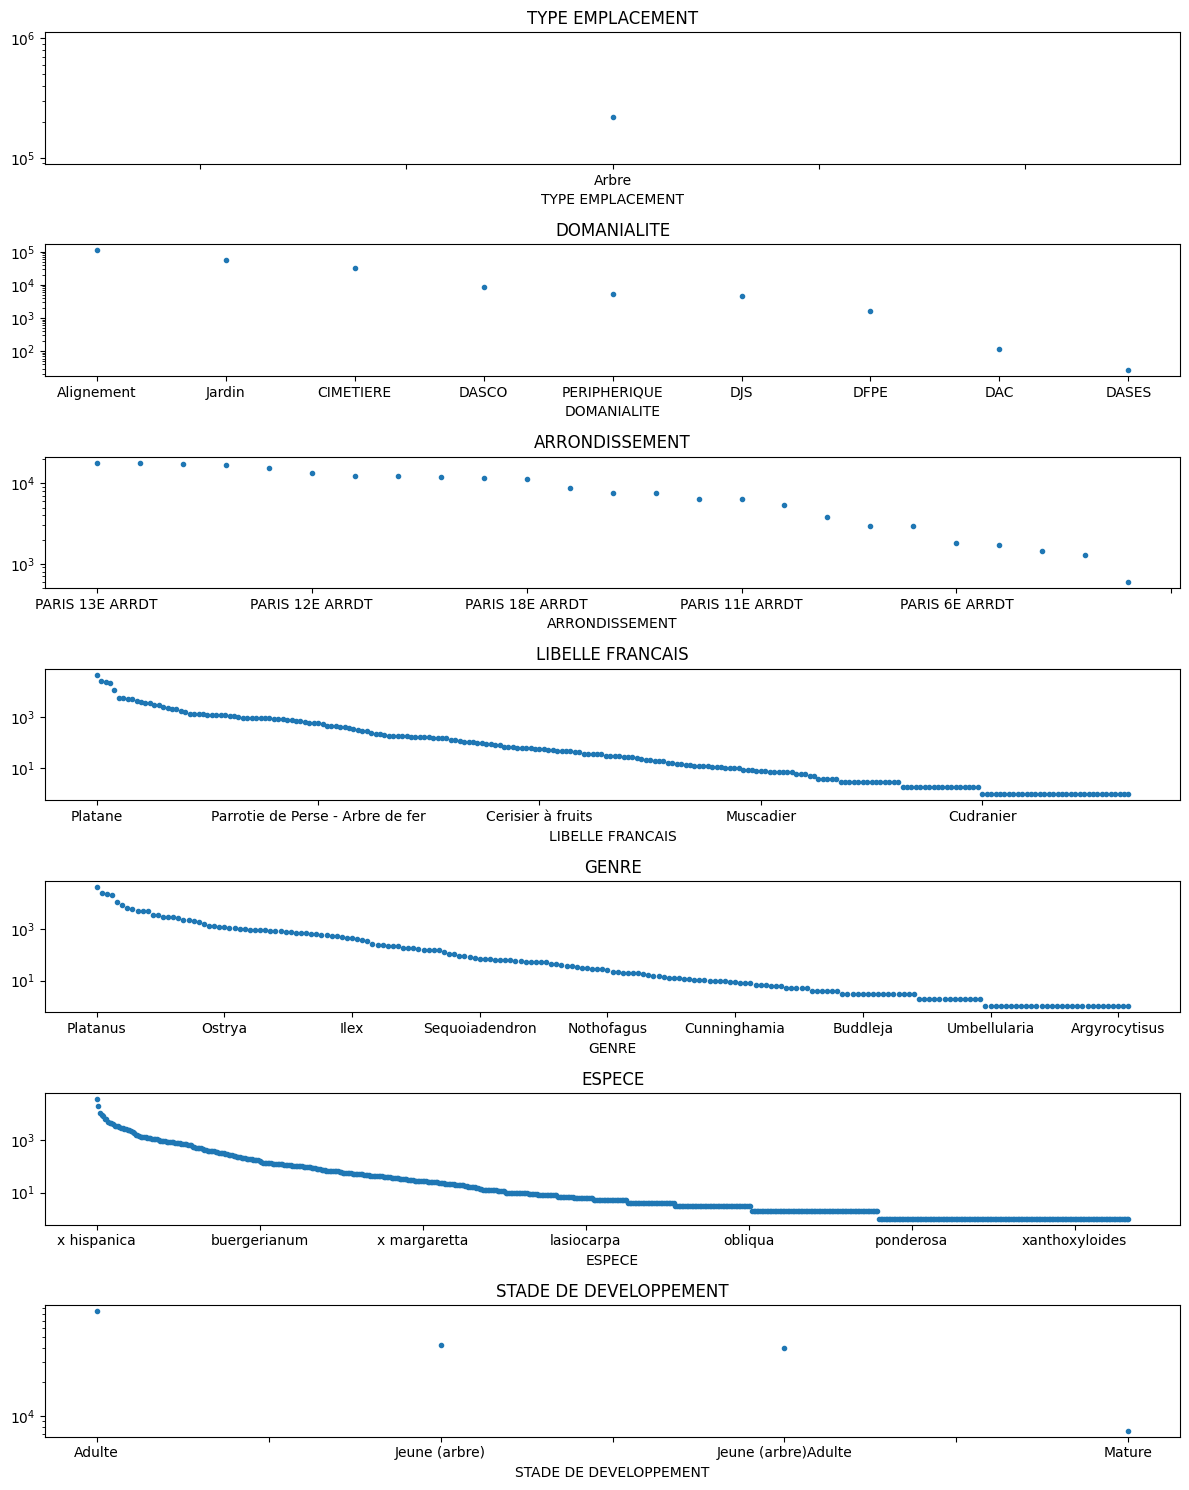

In [62]:
fig, axes = plt.subplots(ncols=1, nrows=7, figsize=(12, 15))

# Non numericalf eatures
df_non_numerical = df.select_dtypes(exclude="number")

for col, ax in zip(df_non_numerical.columns, axes.ravel()):
    df_non_numerical[col].value_counts().plot(
            logy=True, title=col, lw=0, marker=".", ax=ax
    )

plt.tight_layout()

## Conclusion of quality investigation
We identified columns that won't be necessary for our analysis. We also identified possible errors in our data. There can be no tree with height of 10000m. Likewise, a circumference of 200cm (20m) is likely an error considering a 16m tree. We'll further investigate that during our feature investigation.

## Content investigation

### Feature distribution.

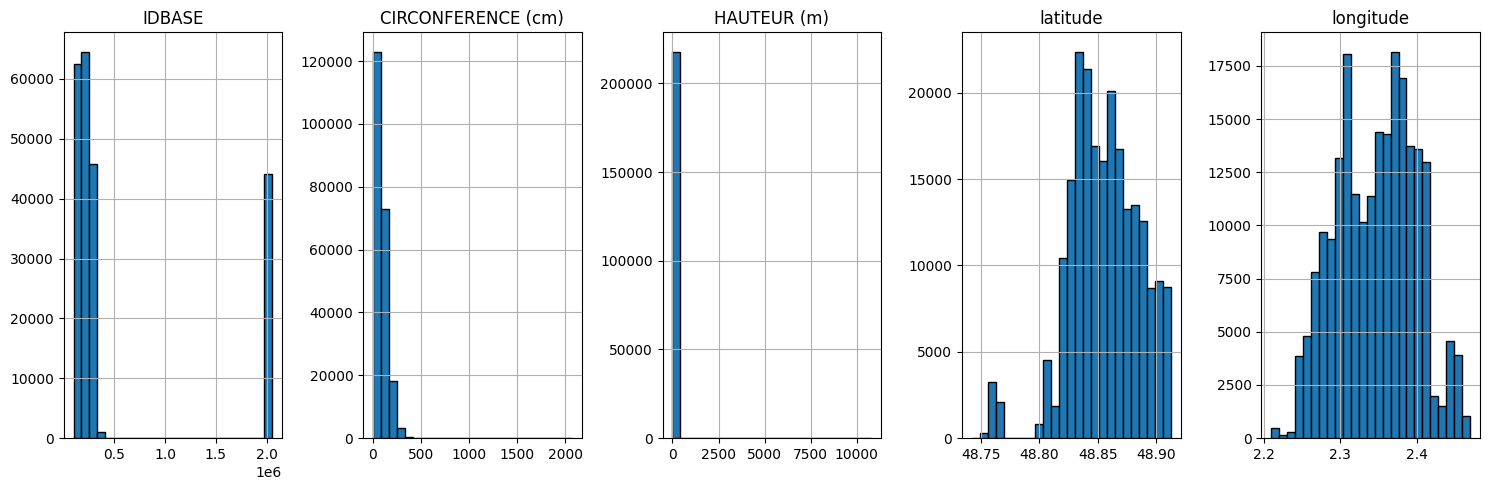

In [65]:
df.hist(bins=25, figsize=(15, 5), layout=(-1, 5), edgecolor="black")
plt.tight_layout()

We can already see that `circonference` and `hauteur` are influenced by some outliers. We don't want that in our visualizations. Let's check the ratio of the most frequent entry for each feature and visualize this.

TYPE EMPLACEMENT               1.0
DOMANIALITE                0.50526
STADE DE DEVELOPPEMENT    0.388764
GENRE                     0.196266
LIBELLE FRANCAIS          0.196193
dtype: Float64

<Axes: >

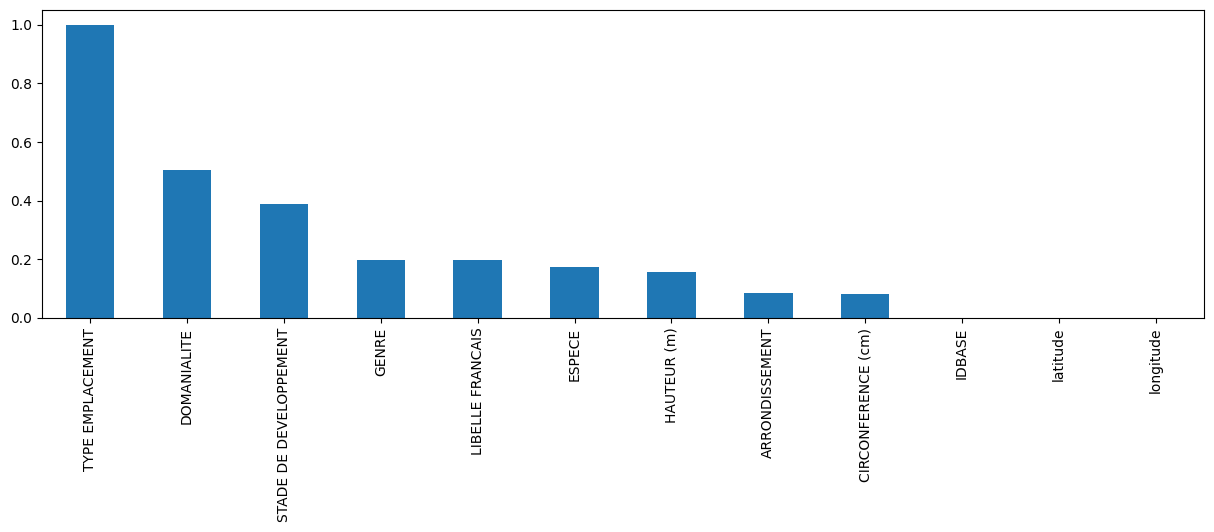

In [68]:
most_frequent_entry = df.mode().iloc[0]

# For each entry, check if it contains the most frequent entry
df_freq = df.eq(most_frequent_entry.values, axis=1)

# Computes the mean of is_most_frequent  occurence
df_freq = df_freq.mean().sort_values(ascending=False)

display(df_freq.head())

df_freq.plot.bar(figsize=(15, 4))

### Feature patterns
#### Continuous features

In [81]:
df_clean = df.loc[
    (df["HAUTEUR (m)"].between(0, 50)) &
    (df["CIRCONFERENCE (cm)"].between(0, 750))
]
df_clean.describe()

,IDBASE,CIRCONFERENCE (cm),HAUTEUR (m),latitude,longitude
count,2.178330e+05,217833.0,217833.0,217833.000000,217833.000000
mean,5.762712e+05,82.341551,8.997774,48.855299,2.347303
std,7.332741e+05,63.073624,5.88488,0.029954,0.051254
min,9.987400e+04,0.0,0.0,48.742290,2.210241
25%,1.641750e+05,31.0,5.0,48.835677,2.307234
50%,2.366810e+05,73.0,8.0,48.855217,2.350699
75%,2.941810e+05,117.0,12.0,48.877090,2.385823
max,2.055199e+06,750.0,45.0,48.912160,2.469752


In [82]:
cols_continuous = df_clean.select_dtypes(include="number").nunique() >= 25
df_continuous = df_clean[cols_continuous[cols_continuous].index]
df_continuous.shape

(217833, 5)

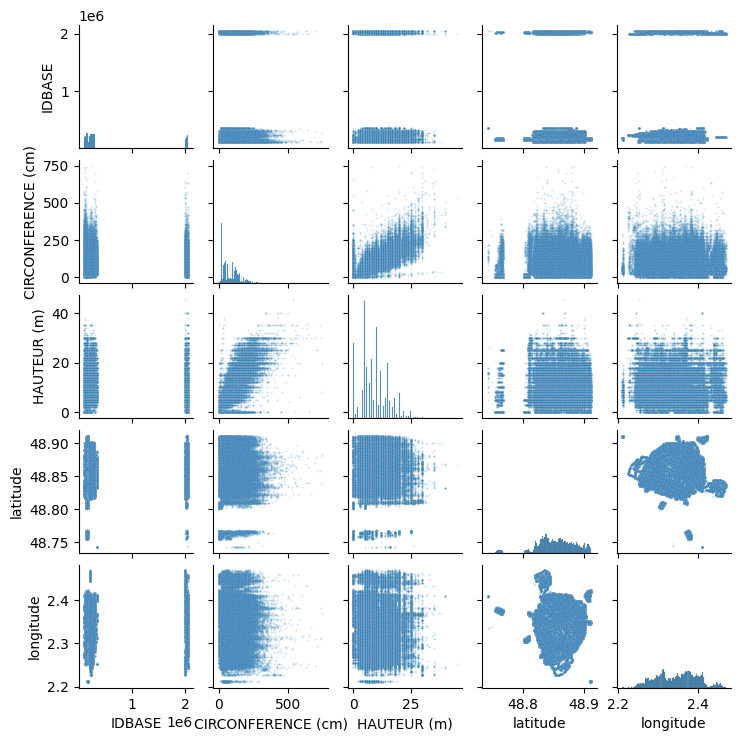

In [83]:
sns.pairplot(df_continuous, height=1.5, plot_kws={"s": 2, "alpha": 0.2})

## Correlations

In [80]:
df_corr = df_clean.corr(method="pearson", numeric_only=True)
df_corr

,IDBASE,CIRCONFERENCE (cm),HAUTEUR (m),latitude,longitude
IDBASE,1.000000,-0.191836,-0.157922,-0.004422,0.153398
CIRCONFERENCE (cm),-0.191836,1.000000,0.839084,0.068853,-0.036029
HAUTEUR (m),-0.157922,0.839084,1.000000,0.079748,-0.059493
latitude,-0.004422,0.068853,0.079748,1.000000,-0.007520
longitude,0.153398,-0.036029,-0.059493,-0.007520,1.000000


In [87]:
df.columns

Index(['IDBASE', 'TYPE EMPLACEMENT', 'DOMANIALITE', 'ARRONDISSEMENT',
       'LIBELLE FRANCAIS', 'GENRE', 'ESPECE', 'CIRCONFERENCE (cm)',
       'HAUTEUR (m)', 'STADE DE DEVELOPPEMENT', 'latitude', 'longitude'],
      dtype='str')

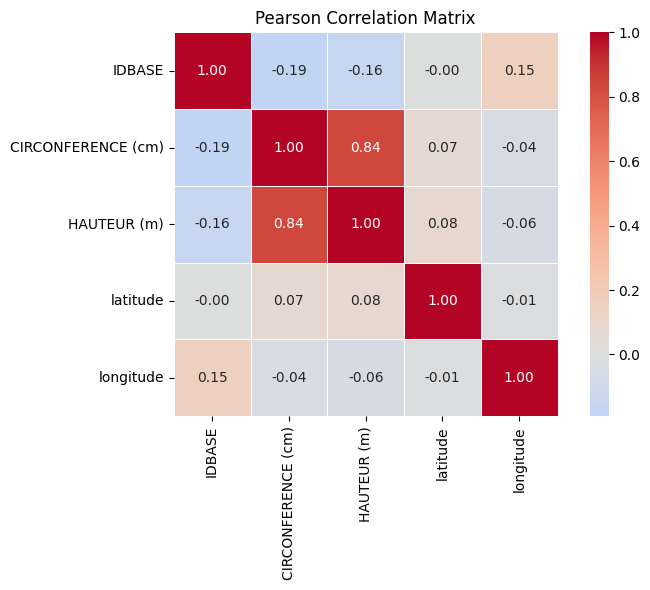

In [84]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Pearson Correlation Matrix")
plt.tight_layout()

# Conclusion
We did a quick EDA attempting at understanding our data:
**Columns to drop
**
- Already identified: TYPE_EMPLACEMENT, COMPLEMENT ADRESSE, LIEU / ADRESSE, IDEMPLACEMENT, VARIETE OUCULTIVAR, REMARQUABLE
- These have high missingness and won't be used in the visualization

**Columns to engineer**
- Split geo_point_2d → latitude + longitude (already done in EDA, needs to be in the pipeline)

**Outlier filtering**
- HAUTEUR (m): keep between 0 and 50
- CIRCONFERENCE (cm): keep between 0 and 750

**Columns to keep for Tableau**
- IDBASE — unique tree identifier
- HAUTEUR (m) — height
- CIRCONFERENCE (cm) — girth
- latitude, longitude — for mapping
- Categorical columns: likely ARRONDISSEMENT, GENRE, ESPECE, STADE_DEVELOPPEMENT (for filtering/grouping in Tableau)

**What to do in the transform step**
- Drop irrelevant columns
- Split coordinates
- Filter outliers
- Optionally rename columns to cleaner names (recommended for Tableau)
- Save to data/processed/trees_clean.parquet